# Setup libraries 

In [226]:
import Pkg
Pkg.add([
        "CSV",
        "DataFrames",
        "Glob",
        "Makie",
        "CairoMakie",
        "Distributions",
        "HypothesisTests",
        "CategoricalArrays",
        "StatsBase",
        "Printf"
        ])

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [227]:
import CSV
using Printf
using DataFrames
using CategoricalArrays
using Glob
using Makie, CairoMakie
using Statistics, Distributions, HypothesisTests, StatsBase
using ColorSchemes: tab10
using Colors

In [228]:
lerp(a::Color, b::Color, val::AbstractFloat) = (a .+ (val * (b .- a)))
th = Theme(
    colormap = :tab10,
    palette = Attributes(
        color = tab10,
        patchcolor = map(c -> lerp(RGB(1,1,1), c, 0.8f0), tab10)
    ),
    Axis = (
        colorrange = (1,10),
    ),
    # Hist = (
    #     color = tab10[1],
    # ),
)
set_theme!(merge(th))

# Import data

## Import metadata

In [1039]:
players = CSV.read("clean-data/players.csv", DataFrame)
match_metadata = vcat([CSV.read(f, DataFrame) for f in glob("*matches.csv", "clean-data")]...);

## Merge data from different files

In [943]:
colset = [
    "match_id",
    "ElapsedTime",
    "SetNo",
    # "P1GamesWon",
    # "P2GamesWon",
    "SetWinner",
    "GameNo",
    "GameWinner",
    "PointNumber",
    "PointWinner",
    "PointServer",
    "Speed_KMH",
    "P1Score",
    "P2Score",
    "P1PointsWon",
    "P2PointsWon",
    # "P1Ace",
    # "P2Ace",
    # "P1Winner",
    # "P2Winner",
    # "P1DoubleFault",
    # "P2DoubleFault",
    # "P1UnfErr",
    # "P2UnfErr",
    "P1BreakPoint",
    "P2BreakPoint",
    "P1BreakPointWon",
    "P2BreakPointWon",
    # "P1SecondSrvIn",
    # "P2SecondSrvIn",
    # "P1SecondSrvWon",
    # "P2SecondSrvWon",
    # "P1ForcedError",
    # "P2ForcedError"
];

In [944]:
dfs = Dict(basename(f) => CSV.read(f, DataFrame) for f in glob("*points.csv", "tennis-data"))
tournaments = keys(dfs) |> collect |> sort
sorted_dfs = [dfs[t] for t in tournaments]
common_cols = intersect([names(df) for df in sorted_dfs]...);

In [945]:
all_matches = vcat([select!(df, colset) for df in sorted_dfs]...);

### Add player ids

In [946]:
leftjoin!(all_matches, match_metadata[:,[:match_id, :player1id, :player2id]], on = :match_id);

## Remove entire matches when necessary data are missing

In [947]:
df = all_matches
kept = []
required_cols = [
    :P1BreakPoint,
    :P2BreakPoint,
    :PointWinner,
    :PointNumber,
    :player1id,
    :player2id
]
set_grps = groupby(df, [:match_id])
dfg = [grp for grp in set_grps if !any(ismissing.(Matrix(grp[:, required_cols])))];
df = vcat(dfg...)

println("Removed missing matches: $(length(set_grps) - length(dfg))")

Removed missing matches: 2119


## Add year, tournament, and match number

In [948]:
# add tournament and year columns
function from_matchid(mid)
    (year, tmnt) = match(r"(\d{4})-([a-z]+)", mid)
    year = parse(Int, year)
    permutedims([year, tmnt])
end

yr_tmnt = vcat(from_matchid.(df.match_id)...)
insertcols!(df, 2, :Year => yr_tmnt[:,1], :Tmnt => yr_tmnt[:,2]);

In [949]:
insertcols!(df, 4, :MatchNum => missing)
for gdf in groupby(df, :Year)
    gdf[!,:MatchNum] = groupindices(groupby(gdf, :match_id))
end

## Add server columns

In [950]:
### BreakPoint column

df[:,:BreakPoint] = BitVector((df.P1BreakPoint) .+ (df.P2BreakPoint));

### Tiebreaker column

tb_games_ids = [
    Vector(grp[1, [:match_id, :SetNo, :GameNo]]) for grp in 
        groupby(df, [:match_id, :SetNo, :GameNo]) if
        any(Matrix(grp[:, [:P1Score, :P2Score]] .== "1"))
]
insertcols!(df, :Tiebreaker => zeros(Bool, nrow(df)))
for (id, setno, gameno) in tb_games_ids
    idx = df.match_id .== id .&& df.SetNo .== setno .&& df.GameNo .== gameno
    df[idx, :Tiebreaker] .= 1
end

### ServerWon column

insertcols!(df, :ServerWon => zeros(Bool, nrow(df)))
df[df.PointWinner .== df.PointServer, :ServerWon] .= 1;

### ServerId column

transform!(df, 
    [:PointServer, :player1id, :player2id] => 
    ByRow((s, p1, p2) -> s == 1 ? p1 : p2) =>
    :ServerId
);

all_matches = df;

## Reduce data to certain players and matches after 2022

### Keep only men's singles games

In [951]:
function is_mens_single(event_name)
    if ismissing(event_name)
        return false
    end
    event_name ∈ ["Men's Singles", "event_MS"]
end

is_mens_single (generic function with 1 method)

In [1563]:
select!(players, Not(intersect(names(players), ["is_male", "no_matches"])));
select!(match_metadata, Not(intersect(names(match_metadata), ["player_no", "player_id", "is_male"])));

In [1564]:
df = match_metadata
males = Set(Matrix(df[is_mens_single.(df.event_name), [:player1id, :player2id]]))
males1 = df[df.player1id .∈ Ref(males), :player2id]
males2 = df[df.player2id .∈ Ref(males), :player1id]
union!(males, males1, males2)
df.is_male .= false
df[df.player1id .∈ Ref(males) .|| df.player2id .∈ Ref(males), :is_male] .= true
df[df.is_male, :event_name] .= "event_MS"

players.is_male .= false
players[players.id .∈ Ref(males), :is_male] .= true

match_metadata = df;
mdf = df[df.is_male,:];

### Make sure data set contains $n$ games for 10 most played players

In [1079]:
df = stack(match_metadata, 
    [:player1id, :player2id],
    variable_name = :player_no, 
    value_name = :player_id
)
df = innerjoin(all_matches, select(df, [:match_id, :player_id, :player_no]), on = :match_id);

players.avg_speed_kmh .= 0.0
for g in groupby(df, :player_id)
    g.player_no = 1 .+ (g.player_no .== "player2id")
    speed = mean(g[g.PointServer .== g.player_no .&& g.Speed_KMH .> 0, :Speed_KMH])
    players[players.id .== g.player_id[1], :avg_speed_kmh] .= speed
end 

In [1565]:
df = mdf
df = df[df.year .>= 2020 .&& df.year .<= 2024,:]

valid_match_ids = unique(all_matches[all_matches.Year .>= 2020, :match_id])
df = df[df.match_id .∈ Ref(valid_match_ids),:]

df = vcat(
    transform(insertcols(df, 1, :player_no => 1), :player1id => :player_id),
    transform(insertcols(df, 1, :player_no => 2), :player2id => :player_id)
)
df = combine(
    groupby(df,:player_id),
    :, :player_id => length => :no_matches
)

df = sort(df, :no_matches)

leftjoin!(players, unique(select(df, :no_matches, :player_id)), on = :id => :player_id)
pids = last(sort(dropmissing(players[players.is_male,:], :no_matches), :no_matches)[:, :id], 10)
match_ids = Set()
for pid in pids
    mids = df[df.player1id .== pid .|| df.player2id .== pid,:match_id]
    union!(match_ids, sample(mids, 12))
end

df = all_matches[all_matches.match_id .∈ Ref(match_ids),:];

## Save to other dataframe

In [1566]:
data_sub = df;

In [345]:
data_main = df;

## Export data

In [28]:
function write_csv(filename, data; kwargs...)
    bool_cols = names(data, Bool)
    CSV.write(
        filename,
        transform(data, bool_cols .=> ByRow(Int) .=> bool_cols)
    )
end

write_csv (generic function with 1 method)

In [357]:
bool_cols = names(df, Bool)
CSV.write(
    joinpath("clean-data", "master-v1.csv"),
    transform(df, bool_cols .=> ByRow(Int) .=> bool_cols)
)

"clean-data/master-v1.csv"

## Take subset

In [1580]:
# dfg = groupby(df, :match_id)
# dfs = vcat(sample(dfg |> collect, 100)...);
write_csv("clean-data/master-sub.csv", data_sub)

"clean-data/master-sub.csv"

# Analysis

## Initialize dataframe

In [192]:
dbp = df[df.BreakPoint,:]
dbp = dbp[sample(1:nrow(dbp), 1000),:]
dtb = df[df.Tiebreaker,:]
dtb = dtb[sample(1:nrow(dtb), 1000),:]
dany = df[sample(1:nrow(df), 1000),:]
df = vcat(dbp, dtb, dany);

In [1567]:
df = data_sub;

In [265]:
df = data_main[data_main.ServerId .== 1496,:];

## Data characterization

In [1568]:
println(
    "Matches: $(df.match_id |> unique |> length)"
)
println("Points played: $(nrow(df))")
println(
    "Distinct players: $(
        vcat(df.player1id, df.player2id) |> unique |> length
    )"
)

Matches: 109
Points played: 24217
Distinct players: 83


In [1569]:
df2 = df[.! (ismissing.(df.player1id) .|| ismissing.(df.player2id)),:]
plmat = combine(
    groupby(select(df2, [:match_id, :player1id, :player2id]), :match_id),
    [:match_id, :player1id, :player2id] => 
    ((mid, p1, p2) -> hcat(first(mid), first(p1), first(p2))) => 
    [:match_id, :player1id, :player2id]
)

total_matches = vcat(
    select(plmat, :player1id => :id),
    select(plmat, :player2id => :id)
)

player_games = combine(
    groupby(total_matches, :id),
    :id => (ids -> [length(ids), first(ids)]') => [:no_games, :id],
);
sort!(player_games, :no_games, rev=true);
# player_games = sort(player_games |>, by = pg -> pg[2]);

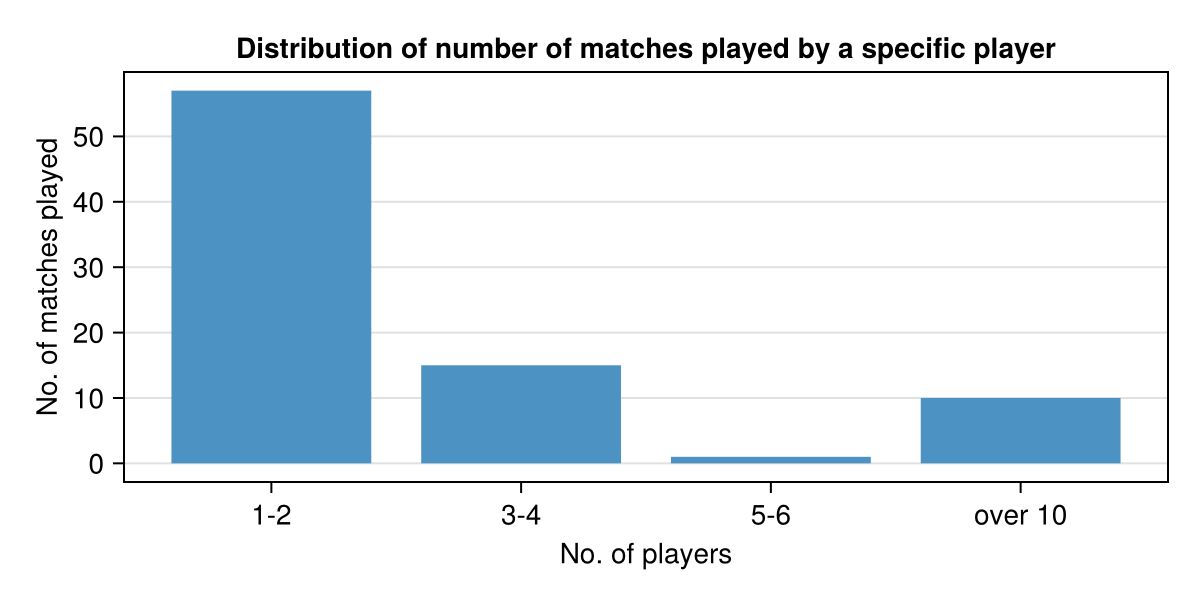

In [1570]:
tmnts = categorical([d.Tmnt[1] for d in groupby(df, :match_id)])
tmnt_counts = countmap(tmnts)

f = Figure(size = (600, 300))

bins = 0:10
labels = ["$(b+1)-$(b+2)" for b in bins[1:end-1]]
npg = cut(player_games.no_games, bins, extend = true, labels = (f,t,i;kw...) -> f)
npg = vcat([[p[1] p[2]] for p in countmap(npg)]...)
npg = npg[sortperm(npg[:,1]),:]

labels = [
    begin
        if lb >= 10
            "over 10"
        else   
            m = 2 * lb - 1
            M = 2 * lb
            "$m-$M"
        end
    end for lb in npg[:,1]
]

ax2 = Axis(f[1,1],
    title = "Distribution of number of matches played by a specific player",
    xlabel = "No. of players",
    ylabel = "No. of matches played",
    xgridvisible = false,
    # xticksvisible = false,
    # xticklabelsvisible = false,
    xticks = (1:size(npg,1), labels),
    yticks = 0:10:60,
)


plt = barplot!(npg[:,2])

f

In [1439]:
CairoMakie.save(joinpath("figs", "player_freq.png"), f)

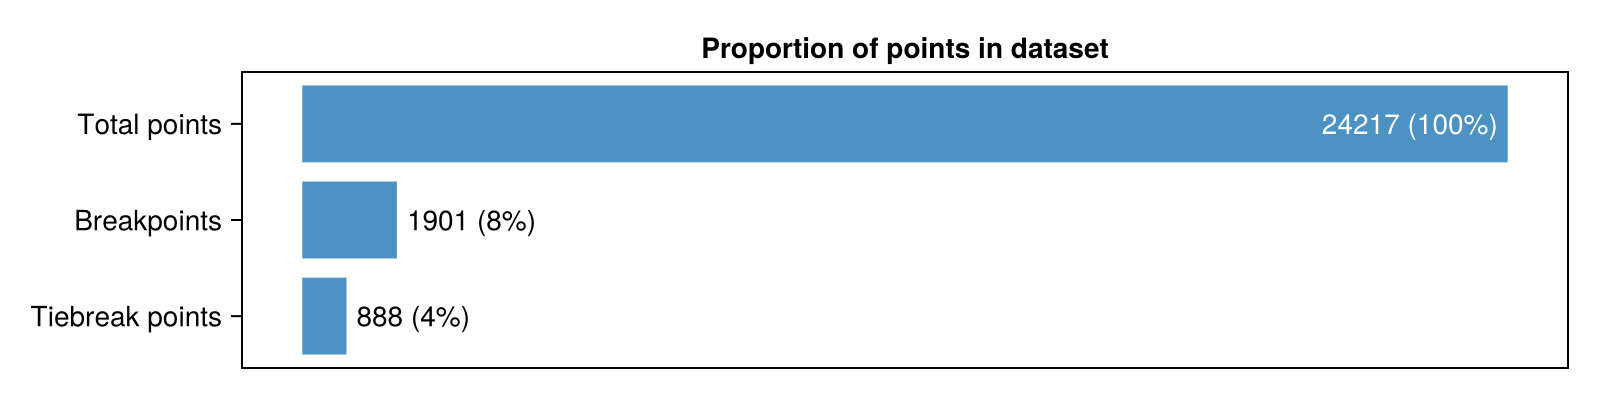

In [1578]:
n_games = nrow(df)
n_bp = nrow(df[df.BreakPoint,:])
n_tb = nrow(df[df.Tiebreaker,:])
bars = [n_games, n_bp, n_tb]
labels = [
    replace(
        @sprintf("%d (%.2d%%)", b, round(100 * b/n_games, sigdigits=2)),
        r"e\+0" => "e"
    ) for b in bars
]

plt = barplot(
    [3,2,1],
    bars,
    axis = (
        title = "Proportion of points in dataset",
        yticks = (1:3, ["Tiebreak points", "Breakpoints", "Total points"]),
        xticksvisible = false,
        xticklabelsvisible = false,
        xgridvisible = false,
        ygridvisible = false,
    ),
    bar_labels = labels,
    direction = :x,
    figure = (
        size = (800, 200),
    ),
    color_over_bar = :white,
    flip_labels_at = 0.85 * n_games,
)

In [1579]:
CairoMakie.save(joinpath("figs", "pointprops.png"), plt)

## Histogram of win probabilities

In [1572]:
gdf = groupby(df, [:match_id]);

In [1573]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    gbp = g[g.BreakPoint,:]
    bpsw = mean(gbp.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    bpws[i] = bpsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, bpws);
# filter!((!) ∘ iszero, bps);

In [1574]:
println("Server wins:")
println("Mean: $(mean(pws))")
println("SD: $(std(pws))\n")

println("Breakpoint server wins:")
println("Mean: $(mean(bpws))")
println("SD: $(std(bpws))")

Server wins:
Mean: 0.6399646372692579
SD: 0.05011439712829983

Breakpoint server wins:
Mean: 0.5847095615873035
SD: 0.1506861458570686


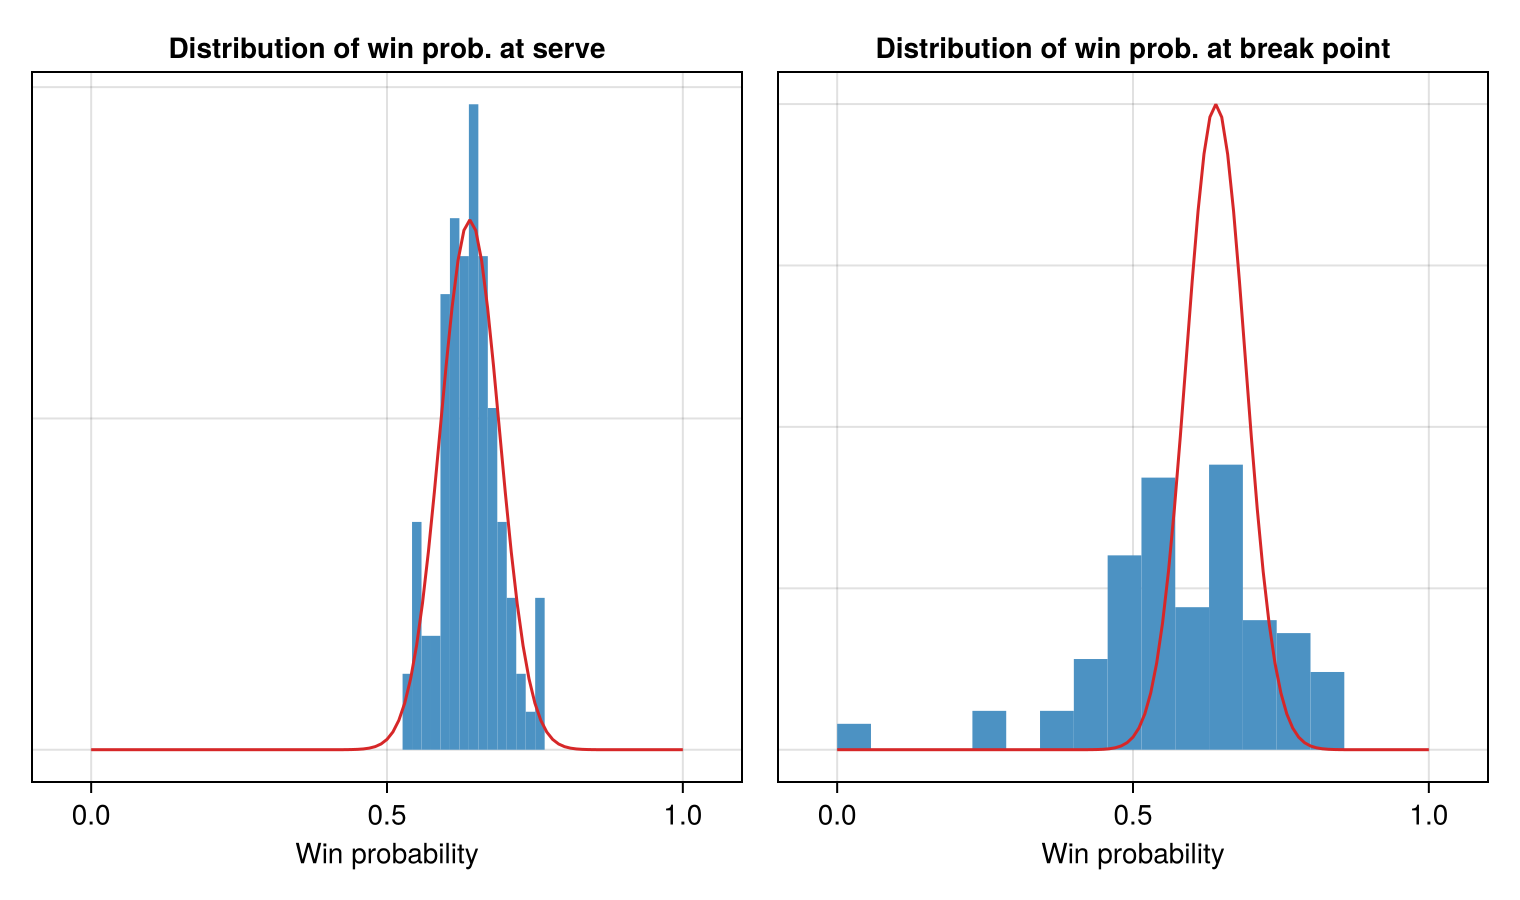

In [1575]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at break point")
hist!(bpws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [1556]:
mean(bpws)

0.5916075684242944

In [1432]:
CairoMakie.save("figs/win_prob_hists.png", f)

In [1576]:
pws = zeros(length(gdf))
tbws = zeros(length(gdf))
for (i,g) in enumerate(gdf)
    gtb = g[g.Tiebreaker,:]
    tbsw = mean(gtb.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    tbws[i] = tbsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, tbws);

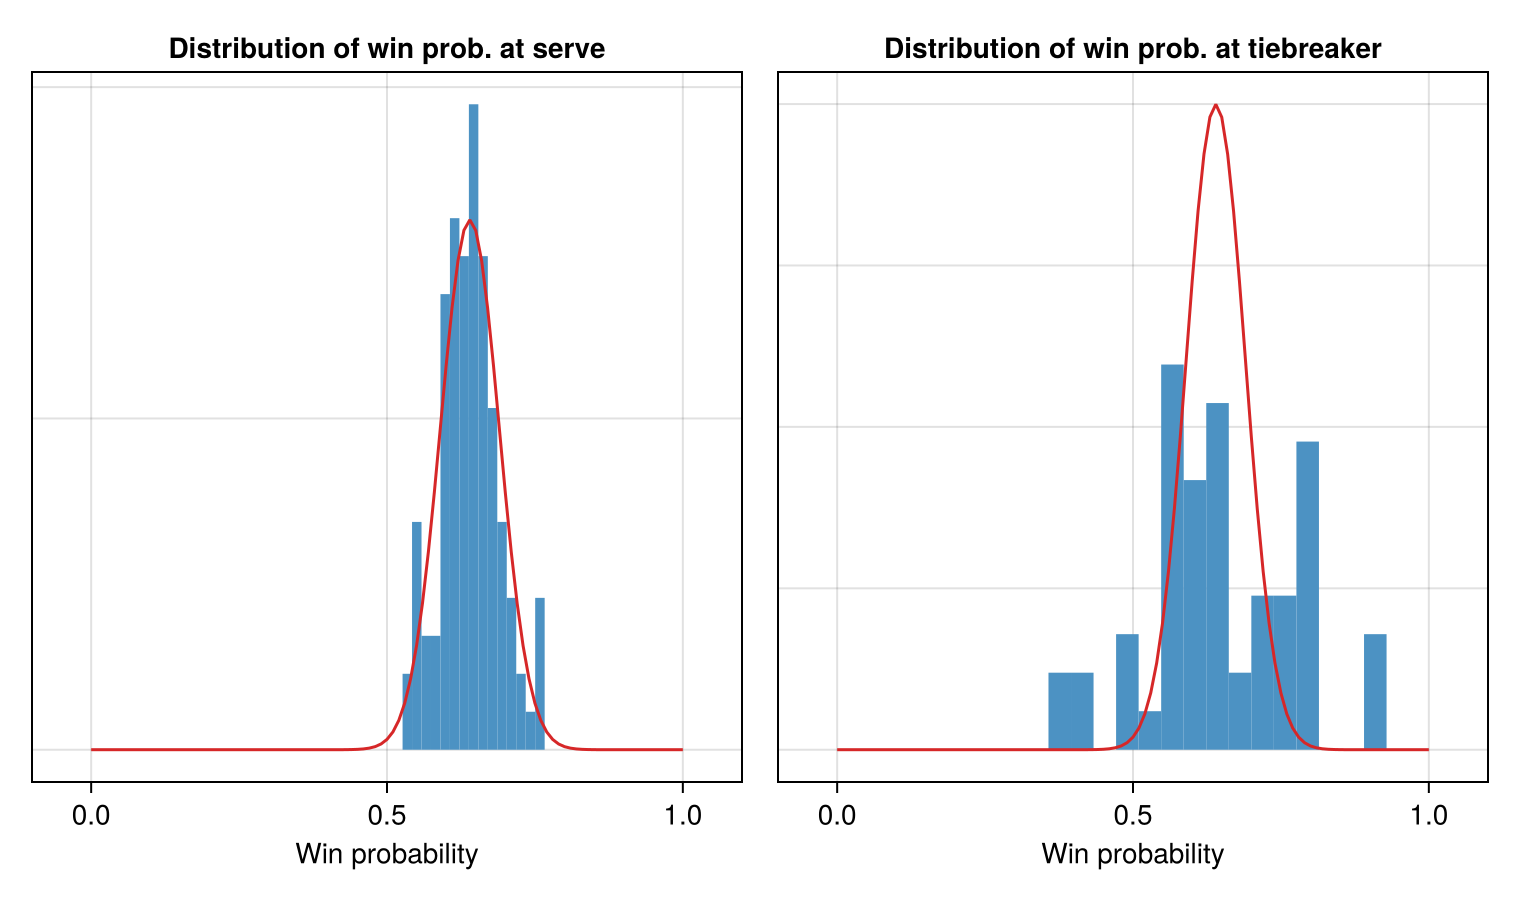

In [1577]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at tiebreaker")
hist!(tbws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [1435]:
CairoMakie.save("figs/win_prob_tb_hists.png", f)

### Goodness of fit test 

We test the probability that the break point serve win probability distribution is the same as the estimated normal distribution of the win serve win probability. We use the fact that, for $X_i \sim N(0,1)$,
$$
\sum_i^n (X_i - \bar{X})^2 \sim \chi_{n-1}^2 \quad \text{where}\quad 
\bar{X} = \frac{1}{n} \sum_i^n X_i.
$$

In [171]:
d = fit(Normal, pws)
T = sum((tbws .- mean(d)).^2) / var(d)
p_pws = 1 - cdf(Chisq(length(tbws)-1), T)

0.0

Then we also do a Kolmogorov-Smirnov test.

In [170]:
pvalue(ApproximateTwoSampleKSTest(pws, skipmissing(bpws) |> collect))

3.452935708006813e-17